# Pipeline for the anomaly detection on the SKAB using MSCRED

Details regarding the SKAB one can find in the [SKAB repository](https://github.com/waico/SKAB).

In [1]:
# libraries importing
import sys
import warnings

import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

sys.path.append("..")
from core.MSCRED_pytorch import MSCRED
from core.metrics import chp_score
from core.utils import load_preprocess_skab, plot_results

warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
%load_ext autoreload
%autoreload 2

## Data

In [3]:
Xy_traintest_list = load_preprocess_skab()

## Method

### Method initialization

In [4]:
# hyperparameters selection
step_max = 10  # maximum step in ConvLSTM
gap_time = 1  # gap time between each segment
win_size = [5, 10, 30]  # window size of each segment
scale_n = len(win_size)
Q = 0.99  # quantile for upper control limit (UCL) selection

In [5]:
def create_dataset(df, win_size, gap_time, step_max):
    data = np.array(df, dtype=np.float64)
    sensor_n = data.shape[1]
    scale_n = len(win_size)

    # normalizacja
    data = MinMaxScaler().fit_transform(data).T  # (sensor_n, T)

    # --- budowanie macierzy korelacji ---
    matrices = []
    T = data.shape[1]

    for win in win_size:
        mats = []
        for t in range(max(win_size), T, gap_time):
            seg = np.zeros((sensor_n, sensor_n))
            for i in range(sensor_n):
                for j in range(i, sensor_n):
                    a = data[i, t-win:t]
                    b = data[j, t-win:t]
                    if len(a) != win or len(b) != win:
                        continue
                    v = np.inner(a, b) / win
                    seg[i, j] = seg[j, i] = v
            mats.append(seg)
        matrices.append(mats)

    matrices = np.transpose(matrices, (1, 2, 3, 0))  # (T', H, W, scale_n)

    # --- sekwencje ---
    X, Y = [], []
    for i in range(step_max, len(matrices)):
        X.append(matrices[i-step_max:i])
        Y.append(matrices[i])

    X = np.array(X)  # (B, step_max, H, W, scale_n)
    Y = np.array(Y)  # (B, H, W, scale_n)
    return X, Y


### Method fitting and applying

In [6]:
mses = []
x = 0

for X_train, X_test, y_train, y_test in Xy_traintest_list:
    x += 1
    print(f"----------------------dataset {x}--------------------------------")

    # dataset
    X_train_, Y_train_ = create_dataset(X_train, win_size, gap_time, step_max)
    X_test_,  Y_test_  = create_dataset(X_test,  win_size, gap_time, step_max)

    sensor_n = X_train_.shape[2]
    PARAMS = [sensor_n, scale_n, step_max]

    # model
    model = MSCRED(PARAMS)
    model.fit(X_train_, Y_train_)

    # predict
    X_pred = model.predict(X_test_)

    resid_mat = Y_test_ - X_pred
    mse = np.mean(np.square(resid_mat), axis=(1, 2))

    t = X_test.index[max(win_size)::gap_time][step_max - 1:]

    min_len = min(len(t), len(mse))
    
    mse_df = pd.DataFrame(
        mse[:min_len],
        index=t[:min_len],
        columns=[f"win_{i}" for i in win_size]
    )

    mses.append(mse_df)


----------------------dataset 1--------------------------------
Epoch 1/10 - loss: 0.027966
Epoch 2/10 - loss: 0.009349
Epoch 3/10 - loss: 0.004895
Epoch 4/10 - loss: 0.003010
Epoch 5/10 - loss: 0.002452
Epoch 6/10 - loss: 0.002076
Epoch 7/10 - loss: 0.001863
Epoch 8/10 - loss: 0.001692
Epoch 9/10 - loss: 0.001522
Epoch 10/10 - loss: 0.001334
----------------------dataset 2--------------------------------
Epoch 1/10 - loss: 0.024456
Epoch 2/10 - loss: 0.005869
Epoch 3/10 - loss: 0.003698
Epoch 4/10 - loss: 0.002917
Epoch 5/10 - loss: 0.002304
Epoch 6/10 - loss: 0.001970
Epoch 7/10 - loss: 0.001689
Epoch 8/10 - loss: 0.001466
Epoch 9/10 - loss: 0.001427
Epoch 10/10 - loss: 0.001280
----------------------dataset 3--------------------------------
Epoch 1/10 - loss: 0.018193
Epoch 2/10 - loss: 0.004167
Epoch 3/10 - loss: 0.002705
Epoch 4/10 - loss: 0.002303
Epoch 5/10 - loss: 0.001959
Epoch 6/10 - loss: 0.001580
Epoch 7/10 - loss: 0.001411
Epoch 8/10 - loss: 0.001252
Epoch 9/10 - loss: 0.0

In [7]:
# inference
predicted_outlier, predicted_cp = [], []
true_outlier, true_cp = [], []
for (X_train, X_test, y_train, y_test), mse_df in zip(Xy_traintest_list, mses):
    t = X_test.index[win_size[-1] :: gap_time][step_max - 1 :]
    UCL = mse_df.quantile(Q) * 2 / 3
    prediction = (
        pd.DataFrame((mse_df > UCL), t).fillna(0).any(axis=1).astype(int)
    )

    # predicted outliers saving
    predicted_outlier.append(prediction)
    # predicted CPs saving
    prediction_cp = abs(prediction.diff())
    prediction_cp.iloc[0] = prediction.iloc[0]
    predicted_cp.append(prediction_cp)

    true_outlier.append(y_test["anomaly"][-len(X_test_) - 1 : -1])
    true_cp.append(y_test["changepoint"][-len(X_test_) - 1 : -1])

    # # plot
    # fig, axes = plt.subplots(1, len(win_size), figsize=(24, 3))
    # fig.suptitle(f"dataset №{x}")
    # for i, col in enumerate(mse_df.columns):
    #     ax = axes.flatten()[int(i)]
    #     ax.hlines(UCL[col], t[0], t[-1], "r")
    #     mse_df[col].plot(ax=ax)
    #     ax.legend()

### Results visualization

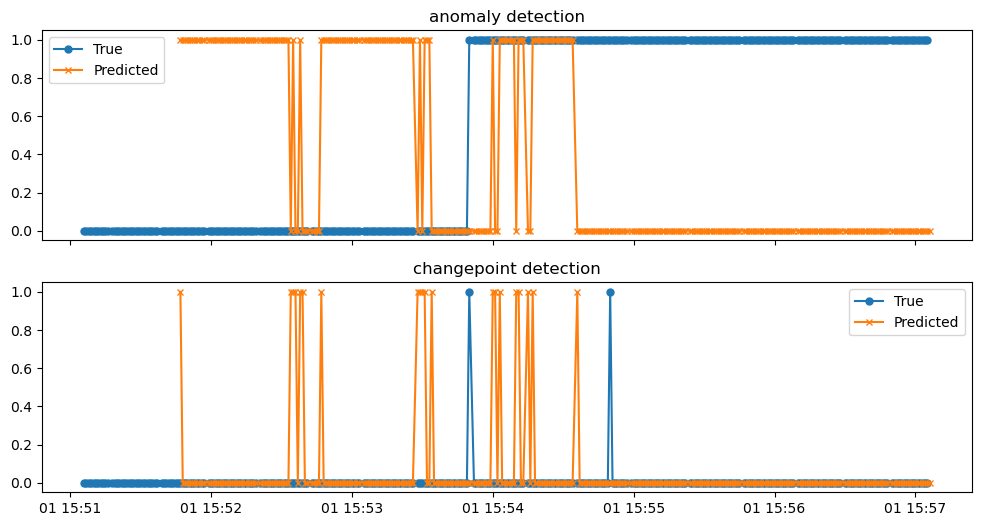

In [8]:
# [donotremove]
plot_results(
    (true_outlier[0], predicted_outlier[0]),
    (true_cp[0], predicted_cp[0]),
)

## Evaluation (metrics calculation)

In [9]:
import pickle

pickle.dump(
    predicted_outlier,
    open(f"../results/results-{model.__class__.__name__}.pkl", "wb"),
)

### Binary classification (outlier detection) metrics

In [10]:
# [donotremove]
# binary classification metrics calculation
binary = chp_score(true_outlier, predicted_outlier, metric="binary")

False Alarm Rate 25.65 %
Missing Alarm Rate 60.72 %
F1 metric 0.52


### Changepoint detection metrics

In [11]:
# [donotremove]
# average detection delay metric calculation
add = chp_score(
    true_cp,
    predicted_cp,
    metric="average_time",
    window_width="60s",
    anomaly_window_destination="righter",
)

Amount of true anomalies 102
A number of missed CPs = 17
A number of FPs = 1668
Average time 0 days 00:00:14.258823


In [12]:
# [donotremove]
# nab metric calculation
nab = chp_score(
    true_cp,
    predicted_cp,
    metric="nab",
    window_width="60s",
    anomaly_window_destination="righter",
)

Standard  -  -15.68
LowFP  -  -106.52
LowFN  -  17.33
